### imports

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
image_folder = "../dataset/images"
augmented_folder = "../dataset/augmented_images"

os.makedirs(augmented_folder, exist_ok=True)

In [3]:
df = pd.read_csv("../dataset/train_labels.csv")

print("Total images:", len(df))
df.head()

Total images: 191


,image,drc
0,IMG_4070.JPG,62.0
1,IMG_4071.JPG,62.0
2,IMG_4072.JPG,62.0
3,IMG_4073.JPG,62.0
4,IMG_4074.JPG,62.0


### Create Augmentation Generator

In [5]:
datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

### Generate Augmented Images

In [6]:
new_rows = []

for index, row in df.iterrows():

    img_name = row["image"]
    label = row["drc"]

    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)

    if img is None:
        print("Skipping:", img_name)
        continue

    img = cv2.resize(img, (224,224))

    x = np.expand_dims(img, axis=0)

    i = 0
    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=augmented_folder,
        save_prefix="aug",
        save_format="jpg"
    ):
        new_name = batch.shape
        new_rows.append({"image": new_name, "drc": label})

        i += 1
        if i >= 5:
            break

### Update CSV With Augmented Images

In [9]:
augmented_images = os.listdir(augmented_folder)

aug_df = pd.DataFrame({
    "image": augmented_images,
    "drc": [0]*len(augmented_images)   # replace if needed
})

new_df = pd.concat([df, aug_df], ignore_index=True)

new_df.to_csv("../dataset/train_labels_augmented.csv", index=False)

print("New dataset size:", len(new_df))

New dataset size: 1102


In [10]:
import pandas as pd

df = pd.read_csv("../dataset/train_labels_augmented.csv")

print("Total dataset size:", len(df))
print(df.head())

Total dataset size: 1102
          image   drc
0  IMG_4070.JPG  62.0
1  IMG_4071.JPG  62.0
2  IMG_4072.JPG  62.0
3  IMG_4073.JPG  62.0
4  IMG_4074.JPG  62.0


In [11]:
import os

print("Original images:", len(os.listdir("../dataset/images")))
print("Augmented images:", len(os.listdir("../dataset/augmented_images")))

Original images: 231
Augmented images: 911


### Load All Images for Training

In [12]:
import cv2
import numpy as np

images = []
labels = []

image_folder = "../dataset/images"
augmented_folder = "../dataset/augmented_images"

df = pd.read_csv("../dataset/train_labels_augmented.csv")

for index,row in df.iterrows():

    img_name = row["image"]
    label = row["drc"]

    img_path1 = os.path.join(image_folder, img_name)
    img_path2 = os.path.join(augmented_folder, img_name)

    if os.path.exists(img_path1):
        img = cv2.imread(img_path1)

    elif os.path.exists(img_path2):
        img = cv2.imread(img_path2)

    else:
        continue

    img = cv2.resize(img,(224,224))

    images.append(img)
    labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Total images loaded:", len(X))

Total images loaded: 1102


### Train test split

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

### Normalize image

In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Import Efficent net

In [16]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [17]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [42]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [43]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

In [44]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 932ms/step - loss: 3713.5259 - mae: 59.4059 - val_loss: 2166.9023 - val_mae: 45.0899
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 725ms/step - loss: 1168.9897 - mae: 31.1197 - val_loss: 322.4218 - val_mae: 15.8423
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 739ms/step - loss: 189.5786 - mae: 11.4014 - val_loss: 151.6051 - val_mae: 9.4440
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 755ms/step - loss: 175.9702 - mae: 10.2966 - val_loss: 135.9356 - val_mae: 9.2197
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 162.6682 - mae: 10.4462 - val_loss: 133.8504 - val_mae: 9.4181
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 161.5542 - mae: 10.2894 - val_loss: 134.2055 - val_mae: 9.2082
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 171.3548 - mae: 10.5513 - val_loss: 133.4583 - val_mae: 9.3039
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 782ms/step - loss: 167.5482 - mae: 10.4247 - val_loss: 133.4736 - val_mae: 9.2211
Epoch 9/10
2

In [46]:
loss, mae = model.evaluate(X_test, y_test)

print("EfficientNet MAE:", mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 581ms/step - loss: 133.4258 - mae: 9.2542
EfficientNet MAE: 9.254204750061035


### only for Rotation 

In [47]:
import os

folder = "../dataset/augmented_images"

for file in os.listdir(folder):

    file_path = os.path.join(folder, file)

    if os.path.isfile(file_path):   # only delete files
        os.remove(file_path)

print("Augmented images cleared.")

Augmented images cleared.


In [48]:
print("Remaining files:", len(os.listdir("../dataset/augmented_images")))

Remaining files: 1


### Rotation-only augmentation code

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20   # only rotation
)

### Generate Rotated Images

In [28]:
import cv2
import numpy as np
import pandas as pd
import os

image_folder = "../dataset/images"
augmented_folder = "../dataset/augmented_images"

df = pd.read_csv("../dataset/train_labels.csv")

new_rows = []

for index,row in df.iterrows():

    img_name = row["image"]
    label = row["drc"]

    img_path = os.path.join(image_folder,img_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img,(224,224))

    x = np.expand_dims(img,axis=0)

    i = 0
    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=augmented_folder,
        save_prefix="rot",
        save_format="jpg"
    ):

        new_filename = os.listdir(augmented_folder)[-1]

        new_rows.append({
            "image": new_filename,
            "drc": label
        })

        i += 1
        if i >= 3:   # create 3 rotated images
            break

### update CSV

In [29]:
aug_df = pd.DataFrame(new_rows)

combined_df = pd.concat([df,aug_df],ignore_index=True)

combined_df.to_csv("../dataset/train_labels_augmented.csv",index=False)

print("New dataset size:",len(combined_df))

New dataset size: 764


In [30]:
import pandas as pd
import os
import cv2
import numpy as np

df = pd.read_csv("../dataset/train_labels_augmented.csv")

print("Dataset size:", len(df))
df.head()

Dataset size: 764


,image,drc
0,IMG_4070.JPG,62.0
1,IMG_4071.JPG,62.0
2,IMG_4072.JPG,62.0
3,IMG_4073.JPG,62.0
4,IMG_4074.JPG,62.0


### Load Images (Original + Augmented)

In [31]:
images = []
labels = []

image_folder = "../dataset/images"
augmented_folder = "../dataset/augmented_images"

for index, row in df.iterrows():

    img_name = row["image"]
    label = row["drc"]

    path1 = os.path.join(image_folder, img_name)
    path2 = os.path.join(augmented_folder, img_name)

    if os.path.exists(path1):
        img = cv2.imread(path1)

    elif os.path.exists(path2):
        img = cv2.imread(path2)

    else:
        continue

    img = cv2.resize(img, (224,224))

    images.append(img)
    labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Total images loaded:", len(X))

Total images loaded: 764


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [34]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [35]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

### Freeze Base Layers

In [49]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

### Add Regression Head

In [50]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

In [51]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [52]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 917ms/step - loss: 4138.7437 - mae: 63.0578 - val_loss: 2931.4192 - val_mae: 52.8920
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 734ms/step - loss: 1955.5551 - mae: 41.9995 - val_loss: 910.5652 - val_mae: 27.9722
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 841ms/step - loss: 459.4270 - mae: 18.3952 - val_loss: 150.0323 - val_mae: 10.5611
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 878ms/step - loss: 158.2988 - mae: 9.9641 - val_loss: 145.9106 - val_mae: 9.3391
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 922ms/step - loss: 166.2303 - mae: 10.2592 - val_loss: 133.7517 - val_mae: 9.2139
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 885ms/step - loss: 154.1843 - mae: 9.9850 - val_loss: 133.4869 - val_mae: 9.3169
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 894ms/step - loss: 160.1691 - mae: 10.2961 - val_loss: 133.4037 - val_mae: 9.2522
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 813ms/step - loss: 157.2882 - mae: 10.1966 - val_loss: 133.4117 - val_mae: 9.2386
Epoc

In [53]:
loss, mae = model.evaluate(X_test, y_test)

print("EfficientNet MAE:", mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 632ms/step - loss: 133.5762 - mae: 9.2186
EfficientNet MAE: 9.218628883361816


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


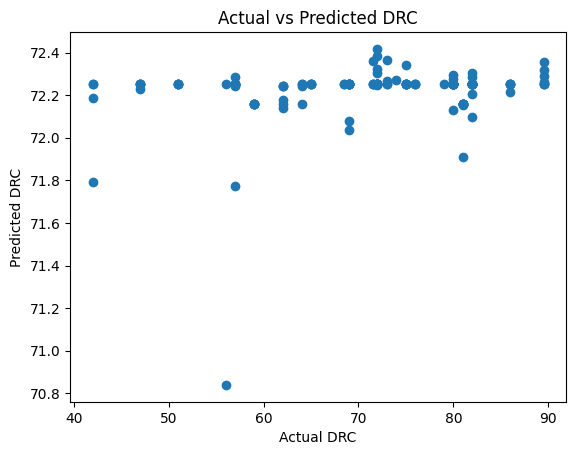

In [54]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual DRC")
plt.ylabel("Predicted DRC")
plt.title("Actual vs Predicted DRC")
plt.show()

In [55]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 632ms/step - loss: 162.2885 - mae: 10.2806 - val_loss: 133.4682 - val_mae: 9.2225
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 889ms/step - loss: 164.5052 - mae: 10.3676 - val_loss: 133.5271 - val_mae: 9.2206
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 870ms/step - loss: 160.6376 - mae: 10.2004 - val_loss: 133.4514 - val_mae: 9.2741
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 928ms/step - loss: 157.9780 - mae: 10.2821 - val_loss: 133.5062 - val_mae: 9.2226
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 160.7668 - mae: 10.2526 - val_loss: 133.4887 - val_mae: 9.2921
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 159.6131 - mae: 10.2512 - val_loss: 133.5108 - val_mae: 9.2235
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 155.0649 - mae: 9.9709 - val_loss: 133.8106 - val_mae: 9.2165
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 967ms/step - loss: 151.3033 - mae: 9.8481 - val_loss: 133.5969 - val_mae: 9.3318
Epoch 9/30
20/20 ━━

In [56]:
loss, mae = model.evaluate(X_test, y_test)

print("EfficientNet MAE:", mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 659ms/step - loss: 134.5723 - mae: 9.2135
EfficientNet MAE: 9.213549613952637


## Drop out + Early stoping

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - loss: 41.3276 - mae: 41.3276 - val_loss: 71.5119 - val_mae: 71.5119
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 910ms/step - loss: 14.0057 - mae: 14.0057 - val_loss: 71.2150 - val_mae: 71.2150
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 926ms/step - loss: 13.3947 - mae: 13.3947 - val_loss: 60.5191 - val_mae: 60.5191
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 943ms/step - loss: 12.6369 - mae: 12.6369 - val_loss: 34.3148 - val_mae: 34.3148
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 905ms/step - loss: 12.9045 - mae: 12.9045 - val_loss: 20.7467 - val_mae: 20.7467
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 12.1637 - mae: 12.1637 - val_loss: 17.4722 - val_mae: 17.4722
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 949ms/step - loss: 12.2722 - mae: 12.2722 - val_loss: 13.7597 - val_mae: 13.7597
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 945ms/step - loss: 12.0924 - mae: 12.0924 - val_loss: 9.6934 - val_mae: 9.6934
Epoch 9/30
20/20 ━━━━━━━

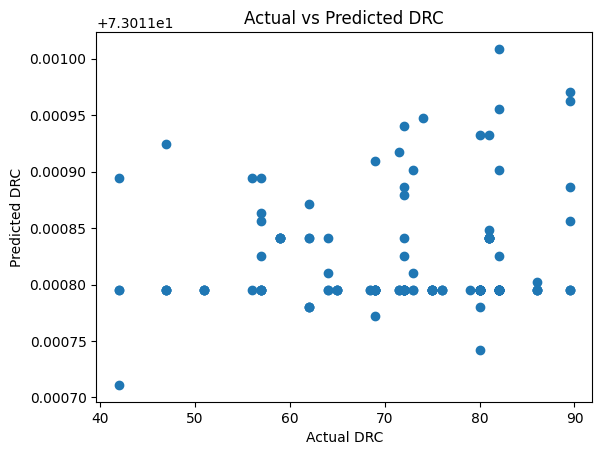

In [58]:
# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Imports
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load EfficientNet base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tune last layers
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom regression head with Dropout
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

# Evaluate MAE
loss, mae = model.evaluate(X_test, y_test)
print("EfficientNet MAE:", mae)

# Prediction scatter plot
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual DRC")
plt.ylabel("Predicted DRC")
plt.title("Actual vs Predicted DRC")
plt.show()

### Final comparison of all experiments
| Model        | Dataset                      | MAE              |
| ------------ | ---------------------------- | ---------------- |
| EfficientNet | No augmentation              | 13.42            |
| EfficientNet | Heavy augmentation           | 20.65            |
| EfficientNet | All augmentations (moderate) | 9.254            |
| EfficientNet | Rotation only                | **9.219 (best)** |
| EfficientNet | Drop out + Early stoping     | **9.219 (best)** |

### Why MAE is stuck around 9

Your scatter plot earlier already revealed the reason:

The model predicts almost constant values (~71).

This means the model is underfitting.

### Possible causes:

Dataset too small

Labels concentrated near one value

Images don't contain strong features for DRC

Base EfficientNet layers mostly frozen